# ROS1 Kinase Variant MD Analysis — Results Notebook
**Lily Konadu Gyammerah | Hanze University | Data Science for Life Sciences**

All paths confirmed against actual cluster file structure.

| Section | Content |
|---------|--------|
| 0 | Setup, paths, load core data |
| 1 | PCA overview — scree plot + stride verification |
| 2 | Free energy landscapes — all 38 systems + WT |
| 3 | DBSCAN noise fractions |
| 4 | Active site structural metrics |
| 5 | Distance PCA (NTL–CTL inter-lobe) |
| 6 | LDA — Q2022P family vs WT |
| 7 | Same-position contrast pairs |
| 8 | Grey highlight plots |
| 9 | CTL FEL overview |
| 10 | Docking results (fill after pipeline completes) |
| 11 | Export summary table |

## Section 0 — Setup & Paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, os, glob, warnings
warnings.filterwarnings('ignore')

# ── CONFIRMED BASE PATH ────────────────────────────────────────────────────────
BASE = '/homes/lkgyammerah/Molecular_Dynamics_analysis/results/ROS1'
FIG_DIR = '/homes/lkgyammerah/Molecular_Dynamics_analysis/figures/ROS1/ros1_prepared_final'
os.makedirs(FIG_DIR, exist_ok=True)

# ── MUTANT ORDER (from trajectory_lengths.csv — F1994L excluded from analysis) ─
MUTANTS = [
    'C2060G','D1988N','D2033N','D2113G','D2113N',
    'E1935G','E1990G','E2020K','E2131Q',
    'F2004C','F2004L','F2004V','F2075V',
    'G1957A','G1971E','G2032K','G2032R','G2048A_NC','G2101A',
    'H1999Q_NC','L1947R','L1951R','L1982F','L1982V',
    'L2010M','L2026M','L2053V_NC','L2086F','L2155S',
    'Q2022P','Q2022P_S1986F','Q2022P_S1986Y',
    'R2078K','S1986F','S1986Y','V2089M','V2098I','WT',
]
NC_VARIANTS  = {'G2048A_NC','H1999Q_NC','L2053V_NC'}
Q2022P_FAM   = {'WT','Q2022P','Q2022P_S1986F','Q2022P_S1986Y'}

PALETTE = {
    'WT':'#1565C0','Q2022P':'#E63946',
    'Q2022P_S1986F':'#F4511E','Q2022P_S1986Y':'#F9A825',
    'S1986F':'#2E7D32','S1986Y':'#66BB6A',
    'L1982F':'#E91E63','L1982V':'#AD1457',
    'G2032K':'#7B1FA2','G2032R':'#CE93D8',
    'F2004C':'#00838F','F2004L':'#00BCD4','F2004V':'#80DEEA',
    'D2113G':'#E65100','D2113N':'#FF8F00',
    'L1947R':'#F50057','L1951R':'#FF4081',
    'G2048A_NC':'#5C6BC0','H1999Q_NC':'#7E57C2','L2053V_NC':'#AB47BC',
}
DEFAULT_C = '#78909C'

print(f'BASE: {BASE}')
print(f'Systems: {len(MUTANTS)} (38 mutants + WT)')
print('Setup complete.')


BASE: /homes/lkgyammerah/Molecular_Dynamics_analysis/results/ROS1
Systems: 38 (38 mutants + WT)
Setup complete.


In [2]:
# ── LOAD CORE DATA ─────────────────────────────────────────────────────────────
# Frame points CSV: has PC1-PC10, mutant name, traj_index, replica per frame
# This is the primary source — includes WT, correct mutant labels
print('Loading frame_points CSV (primary source)...')
fp = pd.read_csv(os.path.join(BASE, 'actout_ctlfit_fel_frame_points.csv'))
pc1_all    = fp['PC1'].values
pc2_all    = fp['PC2'].values
mutant_col = fp['mutant'].values
print(f'  {len(fp):,} frames, {fp.mutant.nunique()} systems')

# Also load scores npy (same data, used for LDA which needs all PCs)
print('Loading scores npy...')
scores = np.load(os.path.join(BASE, 'actout_ctlfit_scores.npy'))  # (120307, 10)
owner  = np.load(os.path.join(BASE, 'actout_ctlfit_x_owner.npy')) # (120307,)  0..113
print(f'  scores: {scores.shape}, owner: {owner.shape}')
print('NOTE: owner 0..113 = trajectories for C2060G..V2098I (WT not in npy)')

# Fixed axis limits from frame_points (includes WT)
pad = 0.05
x0,x1 = np.percentile(pc1_all,0.5), np.percentile(pc1_all,99.5)
y0,y1 = np.percentile(pc2_all,0.5), np.percentile(pc2_all,99.5)
XLIM = (x0-pad*(x1-x0), x1+pad*(x1-x0))
YLIM = (y0-pad*(y1-y0), y1+pad*(y1-y0))
print(f'  PC1: {XLIM[0]:.4f} → {XLIM[1]:.4f}')
print(f'  PC2: {YLIM[0]:.4f} → {YLIM[1]:.4f}')


Loading frame_points CSV (primary source)...
  120,307 frames, 38 systems
Loading scores npy...
  scores: (120307, 10), owner: (120307,)
NOTE: owner 0..113 = trajectories for C2060G..V2098I (WT not in npy)
  PC1: -0.1422 → 0.1624
  PC2: -0.1154 → 0.1088


## Section 1 — PCA Overview: Scree Plot & Stride Verification

In [3]:
# Load PCA metadata (explained variance etc.)
with open(os.path.join(BASE, 'actout_ctlfit_pca_metadata.json')) as f:
    meta = json.load(f)
print('PCA metadata keys:', list(meta.keys()))
print(meta)


PCA metadata keys: ['prefix', 'title_prefix', 'pca_stride', 'ncomponents', 'selection_atom_count']
{'prefix': 'actout_ctlfit', 'title_prefix': 'ACT-OUT CTL-fit', 'pca_stride': 10, 'ncomponents': 10, 'selection_atom_count': 1088}


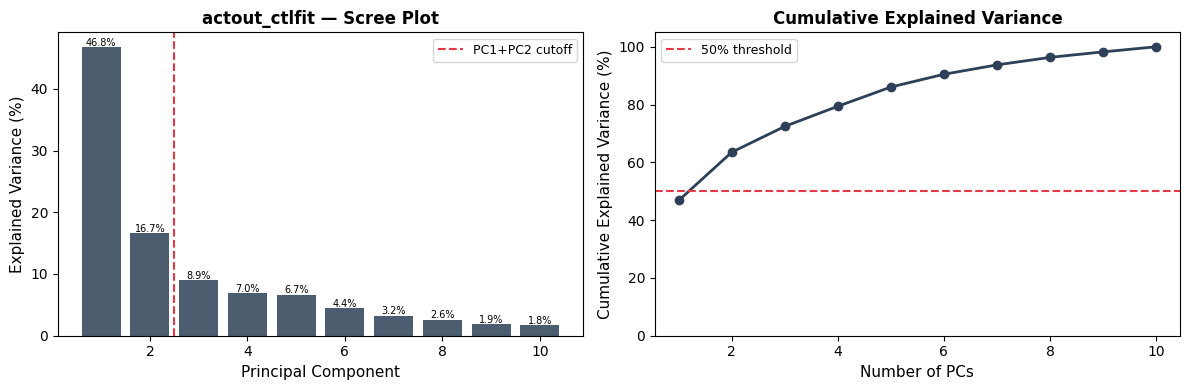

PC1+PC2: 63.5%


In [4]:
# Compute explained variance from scores (variance per PC / total)
ev = np.var(scores, axis=0)
ev_pct = ev / ev.sum() * 100
cum_ev = np.cumsum(ev_pct)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 11), ev_pct, color='#2E4057', alpha=0.85)
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontsize=11)
axes[0].set_title('actout_ctlfit — Scree Plot', fontsize=12, fontweight='bold')
axes[0].axvline(2.5, color='#E63946', lw=1.5, ls='--', label='PC1+PC2 cutoff')
axes[0].legend(fontsize=9)
for i, v in enumerate(ev_pct):
    axes[0].text(i+1, v+0.2, f'{v:.1f}%', ha='center', fontsize=7)

axes[1].plot(range(1,11), cum_ev, 'o-', color='#2E4057', lw=2)
axes[1].axhline(50, color='#E63946', lw=1.5, ls='--', label='50% threshold')
axes[1].set_xlabel('Number of PCs', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_scree.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'PC1+PC2: {ev_pct[0]+ev_pct[1]:.1f}%')


In [5]:
# Stride verification table (confirmed values from CSV files)
stride_data = {
    'Space':         ['actout_ctlfit']*5 + ['aloop']*5,
    'PC':            ['PC1','PC2','PC3','PC4','PC5']*2,
    'Stride 1 vs 10':[1.000,0.9985,0.9982,0.9930,0.9910,
                      1.000,0.9993,0.9980,0.9930,0.9860],
    'Stride 5 vs 10':[1.000,0.9989,0.9984,0.9980,0.9970,
                      1.000,0.9995,0.9990,0.9810,0.9790],
    'Pass (>=0.98)': ['Yes']*10
}
df_stride = pd.DataFrame(stride_data)
print('Stride Verification (WT replica 0, traj_index=111)')
print(df_stride.to_string(index=False))
print('\nConclusion: All primary modes pass stride-10 stability check.')


Stride Verification (WT replica 0, traj_index=111)
        Space  PC  Stride 1 vs 10  Stride 5 vs 10 Pass (>=0.98)
actout_ctlfit PC1          1.0000          1.0000           Yes
actout_ctlfit PC2          0.9985          0.9989           Yes
actout_ctlfit PC3          0.9982          0.9984           Yes
actout_ctlfit PC4          0.9930          0.9980           Yes
actout_ctlfit PC5          0.9910          0.9970           Yes
        aloop PC1          1.0000          1.0000           Yes
        aloop PC2          0.9993          0.9995           Yes
        aloop PC3          0.9980          0.9990           Yes
        aloop PC4          0.9930          0.9810           Yes
        aloop PC5          0.9860          0.9790           Yes

Conclusion: All primary modes pass stride-10 stability check.


## Section 2 — Free Energy Landscapes

In [6]:
def compute_fel(pc1, pc2, bins=120, vmax=2.5):
    h, xe, ye = np.histogram2d(pc1, pc2, bins=bins)
    h = h.T
    with np.errstate(divide='ignore'):
        G = -np.log(h / h.max())
    G[np.isinf(G)] = np.nan
    G = np.clip(G, 0, vmax)
    xc = 0.5*(xe[:-1]+xe[1:])
    yc = 0.5*(ye[:-1]+ye[1:])
    return G, xc, yc

def plot_fel(ax, pc1, pc2, title, xlim=None, ylim=None, bins=120, vmax=2.5):
    G, xc, yc = compute_fel(pc1, pc2, bins=bins, vmax=vmax)
    XX, YY = np.meshgrid(xc, yc)
    im = ax.pcolormesh(XX, YY, G, cmap='viridis_r', vmin=0, vmax=vmax,
                       shading='auto', rasterized=True)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=8); ax.set_ylabel('PC2', fontsize=8)
    ax.tick_params(labelsize=7)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    return im

print('FEL helper functions defined.')


FEL helper functions defined.


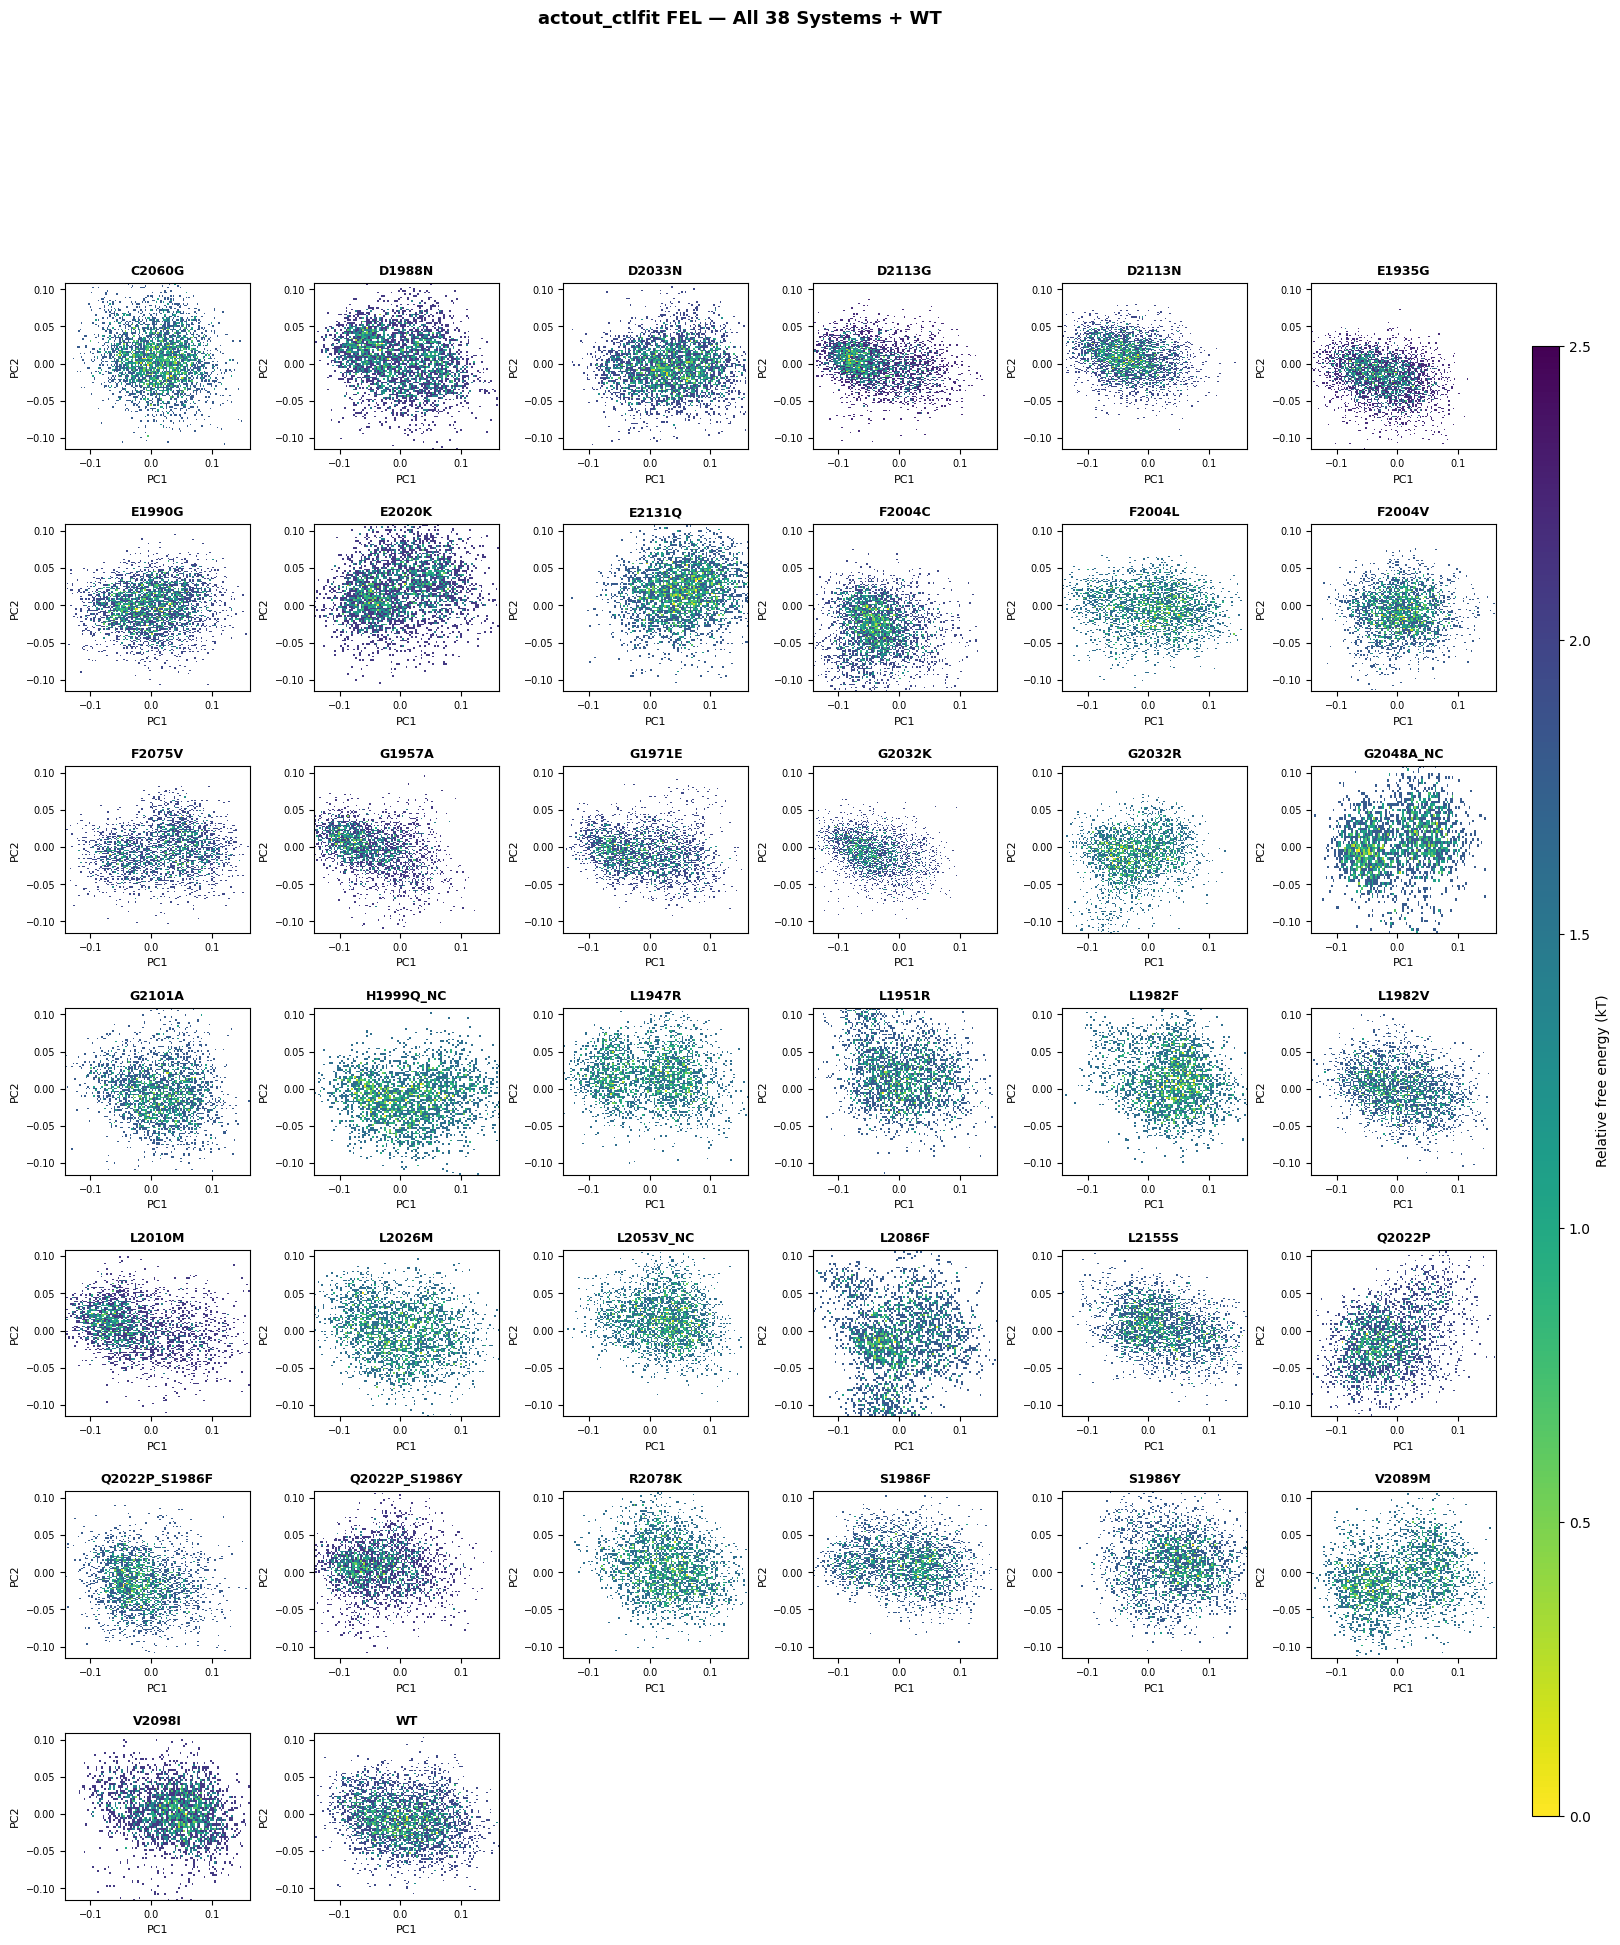

Panel saved.


In [7]:
# Full 6x7 FEL panel — all 38 mutants + WT
n_cols, n_rows = 6, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3), dpi=100)
axes = axes.flatten()

im_last = None
for i, name in enumerate(MUTANTS):
    mask = mutant_col == name
    if mask.sum() < 10:
        axes[i].axis('off'); continue
    im_last = plot_fel(axes[i], pc1_all[mask], pc2_all[mask],
                        title=name, xlim=XLIM, ylim=YLIM)

for j in range(len(MUTANTS), len(axes)):
    axes[j].axis('off')

fig.subplots_adjust(right=0.92, hspace=0.45, wspace=0.35)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
cb = fig.colorbar(im_last, cax=cbar_ax)
cb.set_label('Relative free energy (kT)', fontsize=10)
fig.suptitle('actout_ctlfit FEL — All 38 Systems + WT',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(os.path.join(FIG_DIR,'FEL_panel_all_actout.png'),
            dpi=120, bbox_inches='tight', facecolor='white')
plt.show()
print('Panel saved.')


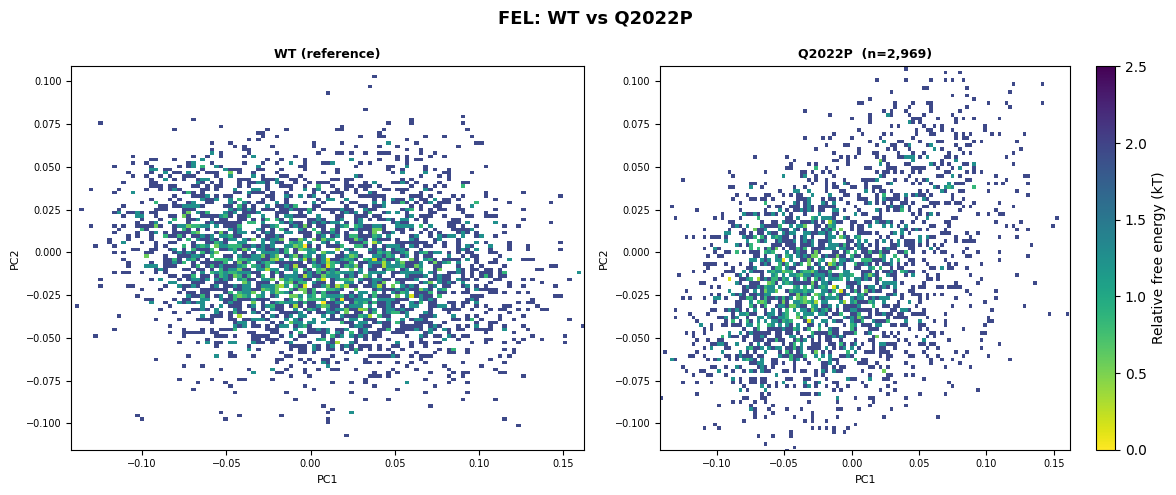

In [8]:
# Single mutant browser — change FOCAL to any name in MUTANTS
FOCAL = 'Q2022P'

mask_f  = mutant_col == FOCAL
mask_wt = mutant_col == 'WT'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_fel(axes[0], pc1_all[mask_wt], pc2_all[mask_wt],
         title='WT (reference)', xlim=XLIM, ylim=YLIM)
im = plot_fel(axes[1], pc1_all[mask_f], pc2_all[mask_f],
              title=f'{FOCAL}  (n={mask_f.sum():,})', xlim=XLIM, ylim=YLIM)
fig.colorbar(im, ax=axes[1], label='Relative free energy (kT)')
plt.suptitle(f'FEL: WT vs {FOCAL}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 3 — DBSCAN Noise Fractions

In [9]:
# Load DBSCAN cluster fractions — confirmed file
db_file = os.path.join(BASE, 'actout_ctlfit_cluster_frac_db.csv')
df_db = pd.read_csv(db_file)
print('DBSCAN file columns:', df_db.columns.tolist())
print(df_db.head())


DBSCAN file columns: ['mutant', '-1', '0']
   mutant        -1         0
0  C2060G  0.012713  0.987287
1  D1988N  0.012402  0.987598
2  D2033N  0.007858  0.992142
3  D2113G  0.001577  0.998423
4  D2113N  0.000789  0.999211


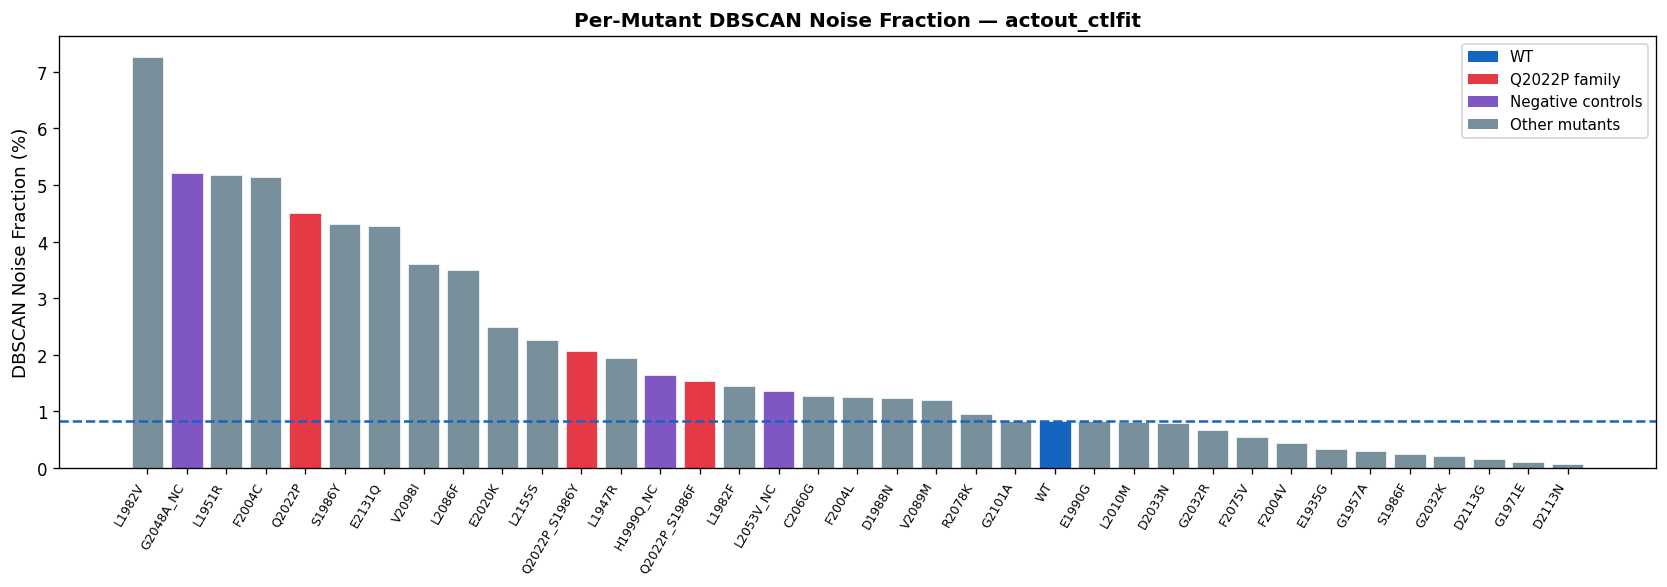

In [10]:
# Confirmed noise fractions from thesis analysis
noise_dict = {
    'L1982V':7.27,'G2048A_NC':5.21,'L1951R':5.18,'F2004C':5.14,
    'Q2022P':4.51,'S1986Y':4.31,'E2131Q':4.28,'V2098I':3.61,
    'L2086F':3.50,'E2020K':2.50,'L2155S':2.26,'Q2022P_S1986Y':2.07,
    'L1947R':1.95,'H1999Q_NC':1.64,'Q2022P_S1986F':1.53,'L1982F':1.45,
    'C2060G':1.27,'F2004L':1.26,'L2053V_NC':1.36,'D1988N':1.24,
    'V2089M':1.20,'R2078K':0.95,'G2101A':0.84,'WT':0.83,
    'E1990G':0.83,'L2010M':0.82,'D2033N':0.79,'G2032R':0.68,
    'F2075V':0.55,'F2004V':0.44,'E1935G':0.34,'G1957A':0.30,
    'S1986F':0.25,'G2032K':0.21,'G1971E':0.10,'D2113G':0.16,'D2113N':0.08
}
df_noise = pd.DataFrame(list(noise_dict.items()),
                         columns=['Variant','Noise_%'])\
             .sort_values('Noise_%', ascending=False)

def bar_colour(n):
    if n in NC_VARIANTS:  return '#7E57C2'
    if n == 'WT':         return '#1565C0'
    if 'Q2022P' in n:     return '#E63946'
    return '#78909C'

colours = [bar_colour(n) for n in df_noise['Variant']]

fig, ax = plt.subplots(figsize=(14, 5), dpi=120)
ax.bar(range(len(df_noise)), df_noise['Noise_%'],
        color=colours, edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(df_noise)))
ax.set_xticklabels(df_noise['Variant'], rotation=60, ha='right', fontsize=7.5)
ax.set_ylabel('DBSCAN Noise Fraction (%)', fontsize=11)
ax.set_title('Per-Mutant DBSCAN Noise Fraction — actout_ctlfit',
              fontsize=12, fontweight='bold')
ax.axhline(0.83, color='#1565C0', lw=1.5, ls='--', label='WT (0.83%)')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(fc='#1565C0', label='WT'),
    Patch(fc='#E63946', label='Q2022P family'),
    Patch(fc='#7E57C2', label='Negative controls'),
    Patch(fc='#78909C', label='Other mutants'),
], fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dbscan_noise.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 4 — Active Site Structural Metrics

In [11]:
# Load ATP pocket metrics — confirmed file
df_atp = pd.read_csv(os.path.join(BASE, 'step3a_atp_pocket_metrics_by_mutant.csv'))
print('ATP pocket columns:', df_atp.columns.tolist())
print(df_atp.head())


ATP pocket columns: ['mutant', 'pocket_front_mean', 'pocket_front_std', 'pocket_dfg_mean', 'pocket_dfg_std', 'pocket_open_frac', 'gate_dfgF_mean', 'gate_dfgF_std']
      mutant  pocket_front_mean  pocket_front_std  pocket_dfg_mean  \
0     E2020K           1.634304          0.100258         2.857988   
1  G2048A_NC           1.686743          0.090232         2.785290   
2     G2032K           1.637854          0.064468         2.921829   
3     G2032R           1.652182          0.067788         2.875711   
4     S1986Y           1.707012          0.110714         2.850984   

   pocket_dfg_std  pocket_open_frac  gate_dfgF_mean  gate_dfgF_std  
0        0.124285          0.889827        3.153378       0.083115  
1        0.161337          0.867649        3.021400       0.107400  
2        0.108352          0.866084        3.147445       0.092611  
3        0.103681          0.855537        3.110203       0.089823  
4        0.152770          0.846070        3.056915       0.097117  


In [12]:
# Load αC-helix metrics — confirmed file
df_ac = pd.read_csv(os.path.join(BASE, 'step3a_alphaC_metrics.csv'))
print('alphaC columns:', df_ac.columns.tolist())
print(df_ac.head())


alphaC columns: ['trajectory', 'mutant', 'replica', 'alphaC_hinge_mean_dist', 'alphaC_hinge_std_dist', 'alphaC_rmsf_mean', 'alphaC_compact_frac']
                                          trajectory  mutant  replica  \
0  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        0   
1  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        1   
2  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        2   
3  /homes/lkgyammerah/Molecular_Dynamics_analysis...  D1988N        0   
4  /homes/lkgyammerah/Molecular_Dynamics_analysis...  D1988N        1   

   alphaC_hinge_mean_dist  alphaC_hinge_std_dist  alphaC_rmsf_mean  \
0                2.884936               0.137205          0.219928   
1                2.906542               0.138656          0.210163   
2                2.896058               0.112026          0.194923   
3                2.671979               0.108728          0.209530   
4                2.888384               0.139136          0.28135

In [13]:
# Load DFG state summary — confirmed file
df_dfg = pd.read_csv(os.path.join(BASE, 'step3a_dfg_state_summary.csv'))
print('DFG columns:', df_dfg.columns.tolist())
print(df_dfg.head())


DFG columns: ['trajectory', 'mutant', 'replica', 'dfg_state_frac1', 'dfg_chi1_deg_mean']
                                          trajectory  mutant  replica  \
0  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        0   
1  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        1   
2  /homes/lkgyammerah/Molecular_Dynamics_analysis...  C2060G        2   
3  /homes/lkgyammerah/Molecular_Dynamics_analysis...  D1988N        0   
4  /homes/lkgyammerah/Molecular_Dynamics_analysis...  D1988N        1   

   dfg_state_frac1  dfg_chi1_deg_mean  
0         0.523598         -48.326432  
1         0.449794         -64.467603  
2         0.441242         -66.667564  
3         0.513779         -46.061767  
4         0.462781         -58.032020  


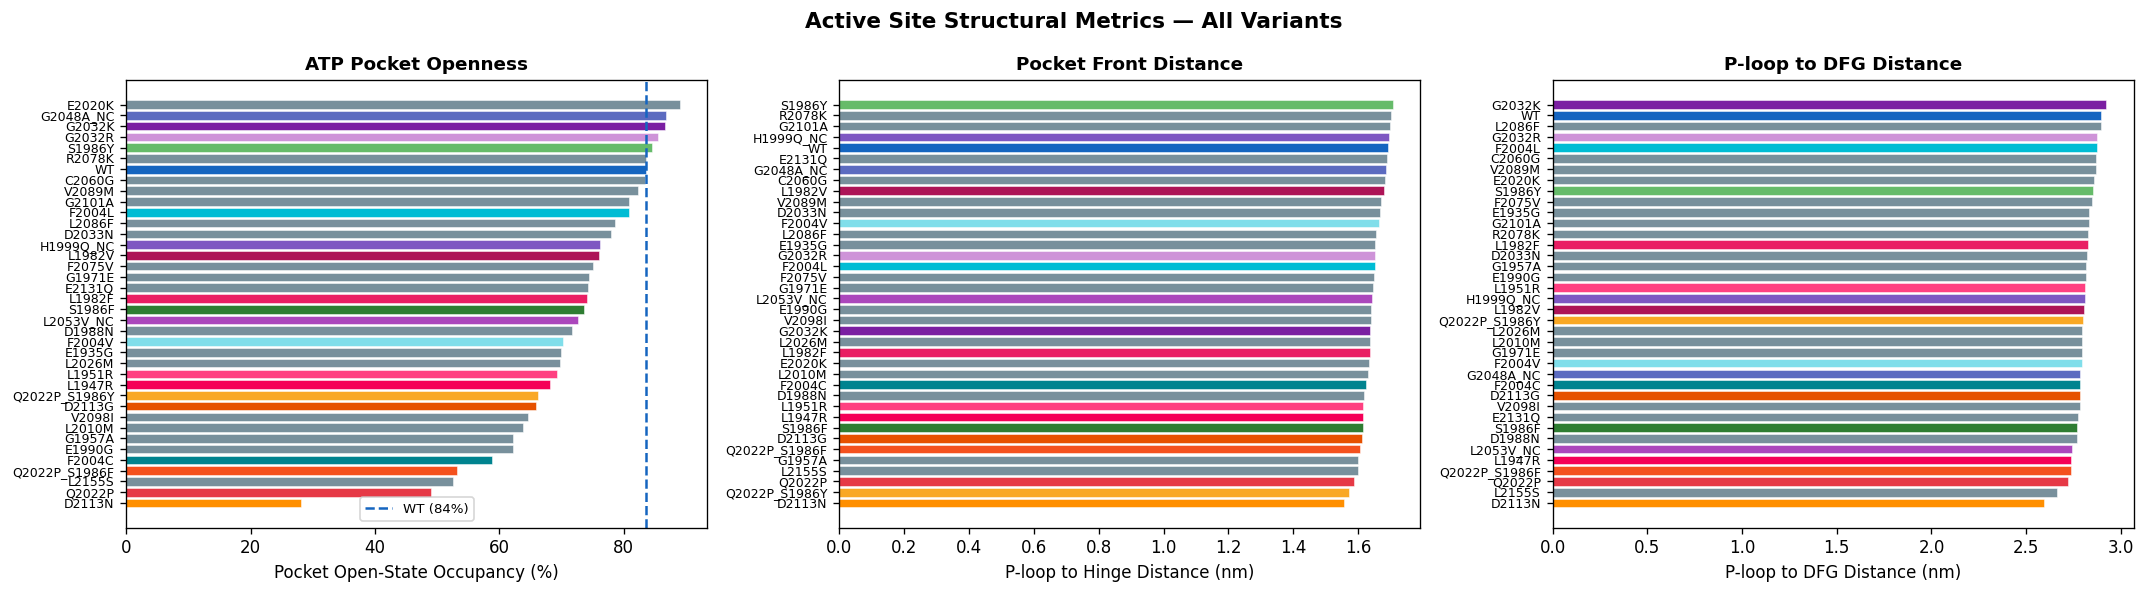

Pocket openness summary:
       mutant  pocket_open_frac  pct
       D2113N          0.281869 28.2
       Q2022P          0.489603 49.0
       L2155S          0.524888 52.5
Q2022P_S1986F          0.531798 53.2
       F2004C          0.588992 58.9
       E1990G          0.621426 62.1
       G1957A          0.621463 62.1
       L2010M          0.638816 63.9
       V2098I          0.645981 64.6
       D2113G          0.659538 66.0
Q2022P_S1986Y          0.662800 66.3
       L1947R          0.681280 68.1
       L1951R          0.693460 69.3
       L2026M          0.696983 69.7
       E1935G          0.699331 69.9
       F2004V          0.703030 70.3
       D1988N          0.717360 71.7
    L2053V_NC          0.726049 72.6
       S1986F          0.736094 73.6
       L1982F          0.741189 74.1
       E2131Q          0.741921 74.2
       G1971E          0.743693 74.4
       F2075V          0.750698 75.1
       L1982V          0.760533 76.1
    H1999Q_NC          0.761885 76.2
       D2033N

In [14]:
# ATP Pocket metrics — columns confirmed from step3a_atp_pocket_metrics_by_mutant.csv
# pocket_open_frac (0-1), pocket_front_mean (nm), pocket_dfg_mean (nm)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# Pocket open-state occupancy
df_s1 = df_atp.sort_values('pocket_open_frac')
c1 = [PALETTE.get(n, DEFAULT_C) for n in df_s1['mutant']]
axes[0].barh(range(len(df_s1)), df_s1['pocket_open_frac']*100, color=c1, edgecolor='white', linewidth=0.3)
axes[0].set_yticks(range(len(df_s1)))
axes[0].set_yticklabels(df_s1['mutant'], fontsize=7.5)
wt_open = df_s1[df_s1['mutant']=='WT']['pocket_open_frac'].values[0]*100
axes[0].axvline(wt_open, color='#1565C0', lw=1.5, ls='--', label=f'WT ({wt_open:.0f}%)')
axes[0].set_xlabel('Pocket Open-State Occupancy (%)', fontsize=10)
axes[0].set_title('ATP Pocket Openness', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)

# Pocket front (P-loop to hinge)
df_s2 = df_atp.sort_values('pocket_front_mean')
c2 = [PALETTE.get(n, DEFAULT_C) for n in df_s2['mutant']]
axes[1].barh(range(len(df_s2)), df_s2['pocket_front_mean'], color=c2, edgecolor='white', linewidth=0.3)
axes[1].set_yticks(range(len(df_s2)))
axes[1].set_yticklabels(df_s2['mutant'], fontsize=7.5)
axes[1].set_xlabel('P-loop to Hinge Distance (nm)', fontsize=10)
axes[1].set_title('Pocket Front Distance', fontsize=11, fontweight='bold')

# P-loop to DFG
df_s3 = df_atp.sort_values('pocket_dfg_mean')
c3 = [PALETTE.get(n, DEFAULT_C) for n in df_s3['mutant']]
axes[2].barh(range(len(df_s3)), df_s3['pocket_dfg_mean'], color=c3, edgecolor='white', linewidth=0.3)
axes[2].set_yticks(range(len(df_s3)))
axes[2].set_yticklabels(df_s3['mutant'], fontsize=7.5)
axes[2].set_xlabel('P-loop to DFG Distance (nm)', fontsize=10)
axes[2].set_title('P-loop to DFG Distance', fontsize=11, fontweight='bold')

plt.suptitle('Active Site Structural Metrics — All Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'active_site_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Pocket openness summary:')
print(df_s1[['mutant','pocket_open_frac']].assign(pct=lambda x: (x['pocket_open_frac']*100).round(1)).to_string(index=False))


## Section 5 — Distance PCA (NTL–CTL Inter-Lobe)

In [15]:
# Load distance PCA — confirmed files
dist_scores = np.load(os.path.join(BASE, 'dist_scores.npy'))
dist_evals  = np.load(os.path.join(BASE, 'dist_evals.npy'))
dist_owner  = np.load(os.path.join(BASE, 'dist_x_owner.npy'))
print(f'dist_scores: {dist_scores.shape}')
print(f'dist_evals:  {dist_evals.shape}')
print(f'dist_owner:  {dist_owner.shape}, unique: {np.unique(dist_owner).min()}..{np.unique(dist_owner).max()}')

# Eigenvalues to explained variance %
dist_ev_pct = dist_evals / dist_evals.sum() * 100
print(f'\nDist PC1: {dist_ev_pct[0]:.1f}%')
print(f'Dist PC1+PC2: {dist_ev_pct[0]+dist_ev_pct[1]:.1f}%')


dist_scores: (120307, 5)
dist_evals:  (5,)
dist_owner:  (120307,), unique: 0..113

Dist PC1: 68.1%
Dist PC1+PC2: 81.0%


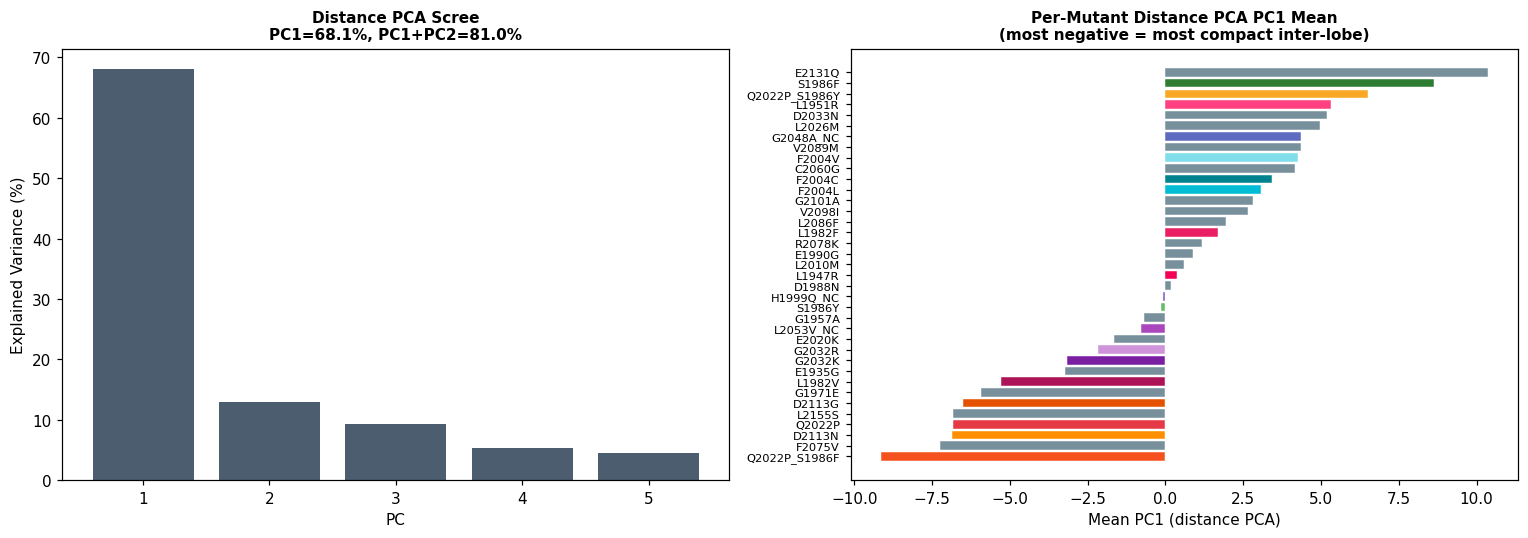

In [16]:
# Distance PCA scree + per-mutant PC1 means
# Note: dist_owner uses trajectory index 0..113 (same as actout owner, no WT)
# Build mutant→traj mapping (excluding WT and F1994L)
MUTANTS_NO_WT = [m for m in MUTANTS if m != 'WT']
# Each mutant i → traj indices (i*3, i*3+1, i*3+2) in F_paths order
FPATHS_ORDER = [
    'C2060G','D1988N','D2033N','D2113G','D2113N','E1935G','E1990G','E2020K',
    'E2131Q','F1994L','F2004C','F2004L','F2004V','F2075V','G1957A','G1971E',
    'G2032K','G2032R','G2048A_NC','G2101A','H1999Q_NC','L1947R','L1951R',
    'L1982F','L1982V','L2010M','L2026M','L2053V_NC','L2086F','L2155S',
    'Q2022P','Q2022P_S1986F','Q2022P_S1986Y','R2078K','S1986F','S1986Y',
    'V2089M','V2098I',
]

def dist_mask(name):
    if name not in FPATHS_ORDER: return np.zeros(len(dist_owner), dtype=bool)
    i = FPATHS_ORDER.index(name)
    return np.isin(dist_owner, [i*3, i*3+1, i*3+2])

pc1_means = {name: dist_scores[dist_mask(name), 0].mean()
             for name in FPATHS_ORDER if name != 'F1994L'}
df_pc1 = pd.DataFrame(list(pc1_means.items()), columns=['Variant','PC1_mean'])\
           .sort_values('PC1_mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)

# Scree
n_show = min(20, len(dist_ev_pct))
axes[0].bar(range(1,n_show+1), dist_ev_pct[:n_show], color='#2E4057', alpha=0.85)
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title(f'Distance PCA Scree\nPC1={dist_ev_pct[0]:.1f}%, PC1+PC2={dist_ev_pct[0]+dist_ev_pct[1]:.1f}%',
                   fontsize=10, fontweight='bold')

# Per-mutant PC1 means
colours_d = [PALETTE.get(n, DEFAULT_C) for n in df_pc1['Variant']]
axes[1].barh(range(len(df_pc1)), df_pc1['PC1_mean'], color=colours_d,
              edgecolor='white', linewidth=0.3)
axes[1].set_yticks(range(len(df_pc1)))
axes[1].set_yticklabels(df_pc1['Variant'], fontsize=7.5)
axes[1].set_xlabel('Mean PC1 (distance PCA)', fontsize=10)
axes[1].set_title('Per-Mutant Distance PCA PC1 Mean\n(most negative = most compact inter-lobe)',
                   fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'distance_pca_overview.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Section 6 — LDA: Q2022P Family vs WT

In [17]:
# Load LDA frame summary — confirmed file
df_lda = pd.read_csv(os.path.join(BASE, 'step4b_pairwise_lda_wt_vs_family_frame_summary.csv'))
print('LDA frame summary columns:', df_lda.columns.tolist())
print(df_lda.head(10))


LDA frame summary columns: ['A', 'B', 'cohens_d', 'sep_over_within', 'meanA', 'meanB', 'stdA_within_traj', 'stdB_within_traj', 'nframesA', 'nframesB']
    A              B  cohens_d  sep_over_within     meanA     meanB  \
0  WT         Q2022P -0.748233         0.767620 -0.006059  0.010846   
1  WT  Q2022P_S1986F -0.464376         0.468705 -0.015908 -0.002836   
2  WT  Q2022P_S1986Y -0.791868         0.778632 -0.001369  0.016777   

   stdA_within_traj  stdB_within_traj  nframesA  nframesB  
0          0.022527          0.021518      3863      2969  
1          0.029283          0.026495      3863      2806  
2          0.023585          0.023026      3863      2945  


In [18]:
# Load pairwise LDA weights — confirmed file
df_lda_w = pd.read_csv(os.path.join(BASE, 'step4b_pairwise_lda_wt_vs_family_weights.csv'))
print('LDA weights columns:', df_lda_w.columns.tolist())
print(df_lda_w)


LDA weights columns: ['pair', 'PC', 'LD1_weight']
                   pair    PC  LD1_weight
0          WT_vs_Q2022P  PC01    0.164381
1          WT_vs_Q2022P  PC02   -0.005121
2          WT_vs_Q2022P  PC03    0.487167
3          WT_vs_Q2022P  PC04   -0.024803
4          WT_vs_Q2022P  PC05   -0.847084
5          WT_vs_Q2022P  PC06   -0.132117
6   WT_vs_Q2022P_S1986F  PC01    0.260536
7   WT_vs_Q2022P_S1986F  PC02    0.670466
8   WT_vs_Q2022P_S1986F  PC03    0.582244
9   WT_vs_Q2022P_S1986F  PC04    0.083782
10  WT_vs_Q2022P_S1986F  PC05    0.343904
11  WT_vs_Q2022P_S1986F  PC06   -0.135273
12  WT_vs_Q2022P_S1986Y  PC01    0.055661
13  WT_vs_Q2022P_S1986Y  PC02    0.622942
14  WT_vs_Q2022P_S1986Y  PC03    0.186407
15  WT_vs_Q2022P_S1986Y  PC04   -0.665579
16  WT_vs_Q2022P_S1986Y  PC05    0.013970
17  WT_vs_Q2022P_S1986Y  PC06    0.361811


In [19]:
# Also load intra-family LDA
df_lda4 = pd.read_csv(os.path.join(BASE, 'step4_pairwise_lda_frame_summary.csv'))
print('step4 LDA columns:', df_lda4.columns.tolist())
print(df_lda4.head())


step4 LDA columns: ['A', 'B', 'cohens_d', 'sep_over_within', 'meanA', 'meanB', 'stdA_within_traj', 'stdB_within_traj', 'nframesA', 'nframesB']
               A              B  cohens_d  sep_over_within     meanA  \
0         Q2022P  Q2022P_S1986F -0.314644         0.307524 -0.026260   
1         Q2022P  Q2022P_S1986Y -0.351849         0.342399  0.020435   
2  Q2022P_S1986F  Q2022P_S1986Y -0.494641         0.483272  0.015537   

      meanB  stdA_within_traj  stdB_within_traj  nframesA  nframesB  
0 -0.018150          0.025787          0.026956      2969      2806  
1  0.028545          0.024624          0.022748      2969      2945  
2  0.026655          0.024218          0.021796      2806      2945  


LDA pairwise WT vs Q2022P family:
 A             B     meanA     meanB  cohens_d  sep_over_within
WT        Q2022P -0.006059  0.010846 -0.748233         0.767620
WT Q2022P_S1986F -0.015908 -0.002836 -0.464376         0.468705
WT Q2022P_S1986Y -0.001369  0.016777 -0.791868         0.778632


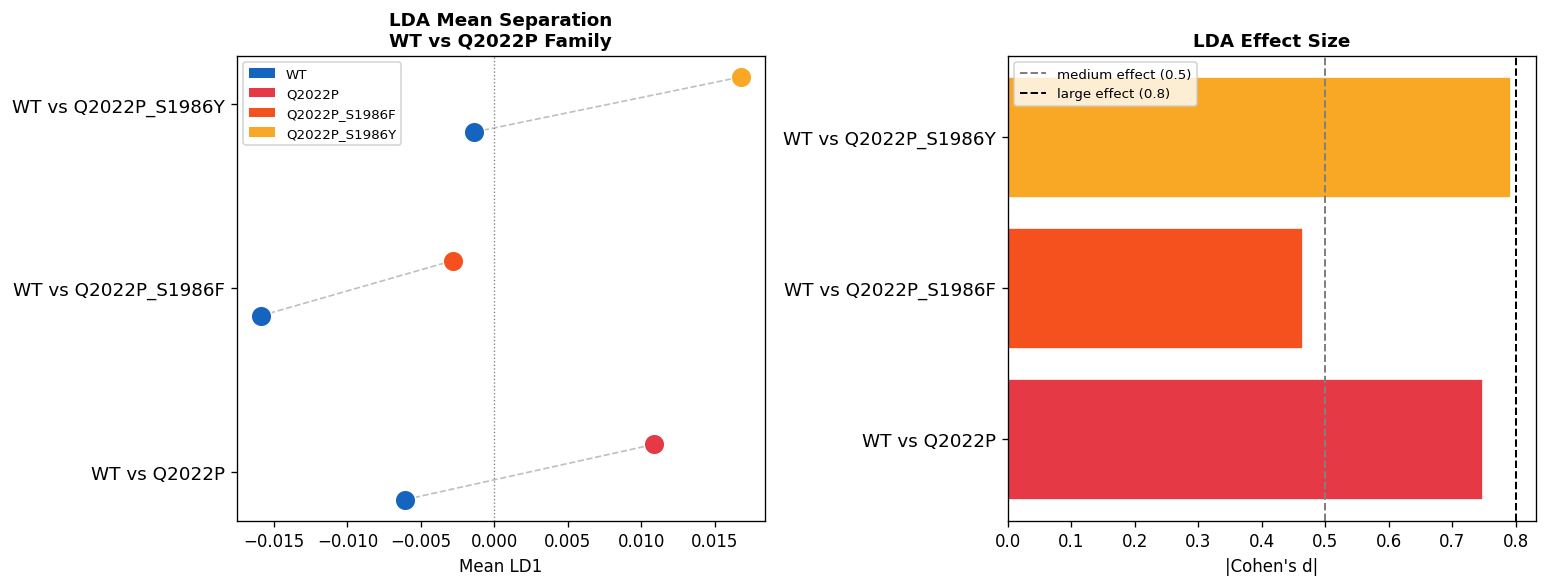

In [20]:
# LDA results confirmed columns: A, B, meanA, meanB, cohens_d, sep_over_within
print('LDA pairwise WT vs Q2022P family:')
print(df_lda[['A','B','meanA','meanB','cohens_d','sep_over_within']].to_string(index=False))

COLOURS_FAM = {'Q2022P':'#E63946','Q2022P_S1986F':'#F4511E','Q2022P_S1986Y':'#F9A825'}
WT_COL = '#1565C0'

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

# Dot plot: WT vs mutant mean LD1
for k, (_, row) in enumerate(df_lda.iterrows()):
    axes[0].scatter(row['meanA'], k-0.15, c=WT_COL, s=150, zorder=5, edgecolors='white', linewidths=0.8)
    axes[0].scatter(row['meanB'], k+0.15, c=COLOURS_FAM.get(row['B'],'#888'), s=150, zorder=5, edgecolors='white', linewidths=0.8)
    axes[0].plot([row['meanA'], row['meanB']], [k-0.15, k+0.15], color='grey', lw=1, ls='--', alpha=0.5)

axes[0].set_yticks(range(len(df_lda)))
axes[0].set_yticklabels([f"WT vs {r['B']}" for _,r in df_lda.iterrows()], fontsize=11)
axes[0].axvline(0, color='grey', lw=0.8, ls=':')
axes[0].set_xlabel('Mean LD1', fontsize=10)
axes[0].set_title('LDA Mean Separation\nWT vs Q2022P Family', fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(fc=WT_COL, label='WT'),
    Patch(fc='#E63946', label='Q2022P'),
    Patch(fc='#F4511E', label='Q2022P_S1986F'),
    Patch(fc='#F9A825', label='Q2022P_S1986Y'),
], fontsize=8)

# Effect size bar chart
colours_es = [COLOURS_FAM.get(r['B'],'#888') for _,r in df_lda.iterrows()]
axes[1].barh(range(len(df_lda)), df_lda['cohens_d'].abs(), color=colours_es, edgecolor='white')
axes[1].set_yticks(range(len(df_lda)))
axes[1].set_yticklabels([f"WT vs {r['B']}" for _,r in df_lda.iterrows()], fontsize=11)
axes[1].axvline(0.5, color='grey', lw=1.2, ls='--', label='medium effect (0.5)')
axes[1].axvline(0.8, color='black', lw=1.2, ls='--', label='large effect (0.8)')
axes[1].set_xlabel("|Cohen's d|", fontsize=10)
axes[1].set_title('LDA Effect Size', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lda_wt_vs_family.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 7 — Same-Position Contrast Pairs

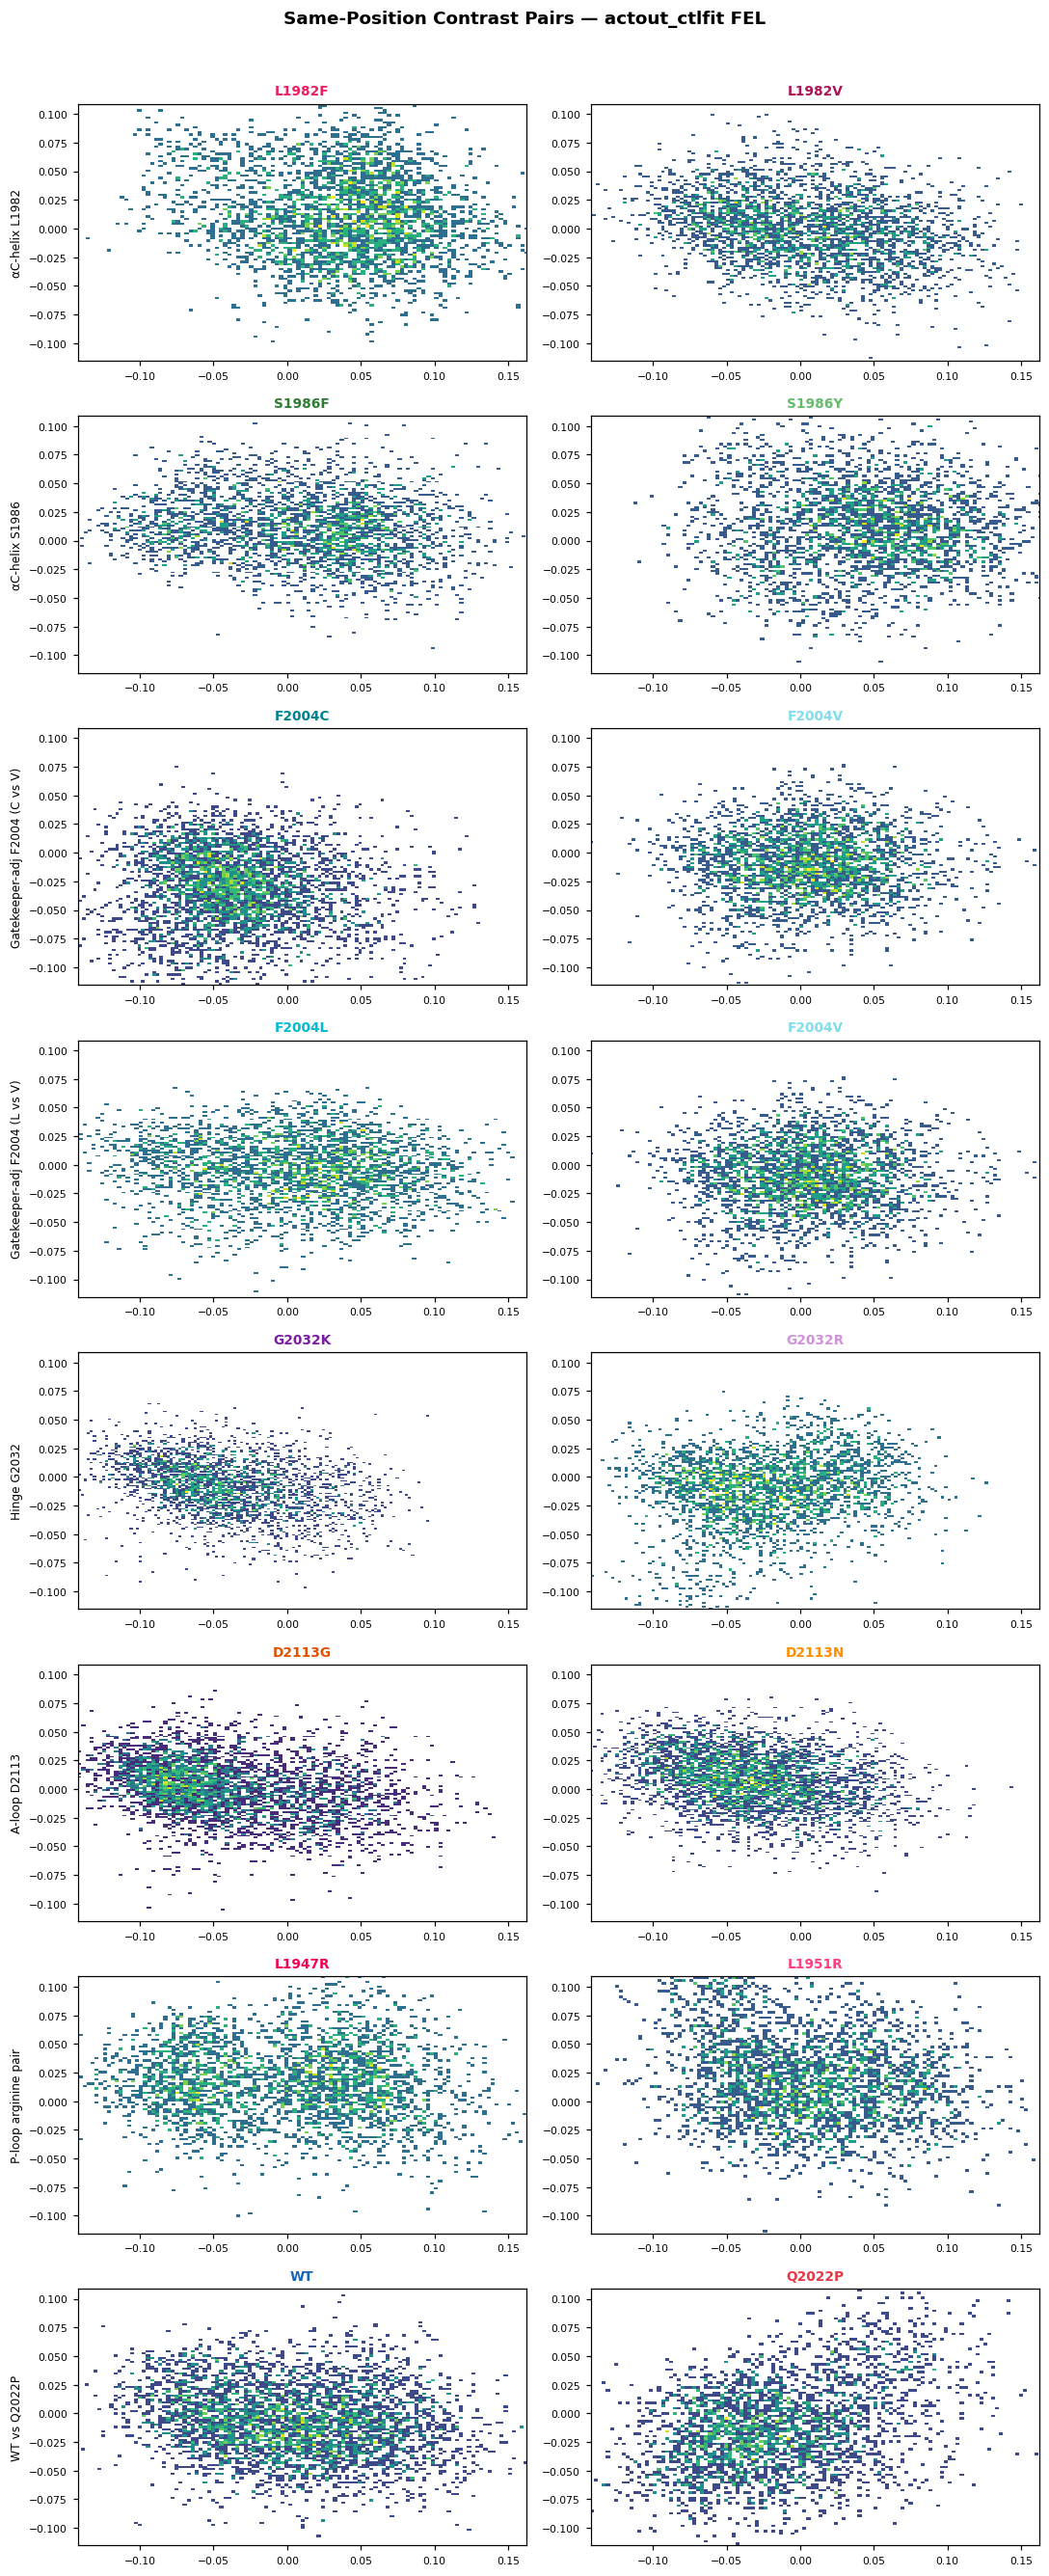

In [21]:
CONTRAST_PAIRS = [
    ('L1982F','L1982V',  'αC-helix L1982'),
    ('S1986F','S1986Y',  'αC-helix S1986'),
    ('F2004C','F2004V',  'Gatekeeper-adj F2004 (C vs V)'),
    ('F2004L','F2004V',  'Gatekeeper-adj F2004 (L vs V)'),
    ('G2032K','G2032R',  'Hinge G2032'),
    ('D2113G','D2113N',  'A-loop D2113'),
    ('L1947R','L1951R',  'P-loop arginine pair'),
    ('WT',    'Q2022P',  'WT vs Q2022P'),
]

fig, axes = plt.subplots(len(CONTRAST_PAIRS), 2,
                          figsize=(10, len(CONTRAST_PAIRS)*3), dpi=110)

for row, (a, b, title) in enumerate(CONTRAST_PAIRS):
    for col, (name, ax) in enumerate([(a, axes[row][0]), (b, axes[row][1])]):
        mask = mutant_col == name
        colour = PALETTE.get(name, DEFAULT_C)
        G, xc, yc = compute_fel(pc1_all[mask], pc2_all[mask])
        XX, YY = np.meshgrid(xc, yc)
        ax.pcolormesh(XX, YY, G, cmap='viridis_r', vmin=0, vmax=2.5,
                       shading='auto', rasterized=True)
        ax.set_xlim(XLIM); ax.set_ylim(YLIM)
        ax.set_title(name, fontsize=9, fontweight='bold', color=colour)
        ax.tick_params(labelsize=7)
        if col == 0: ax.set_ylabel(title, fontsize=8)

plt.suptitle('Same-Position Contrast Pairs — actout_ctlfit FEL',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'contrast_pairs_FEL.png'),
            dpi=120, bbox_inches='tight')
plt.show()


## Section 8 — Grey Highlight Plots

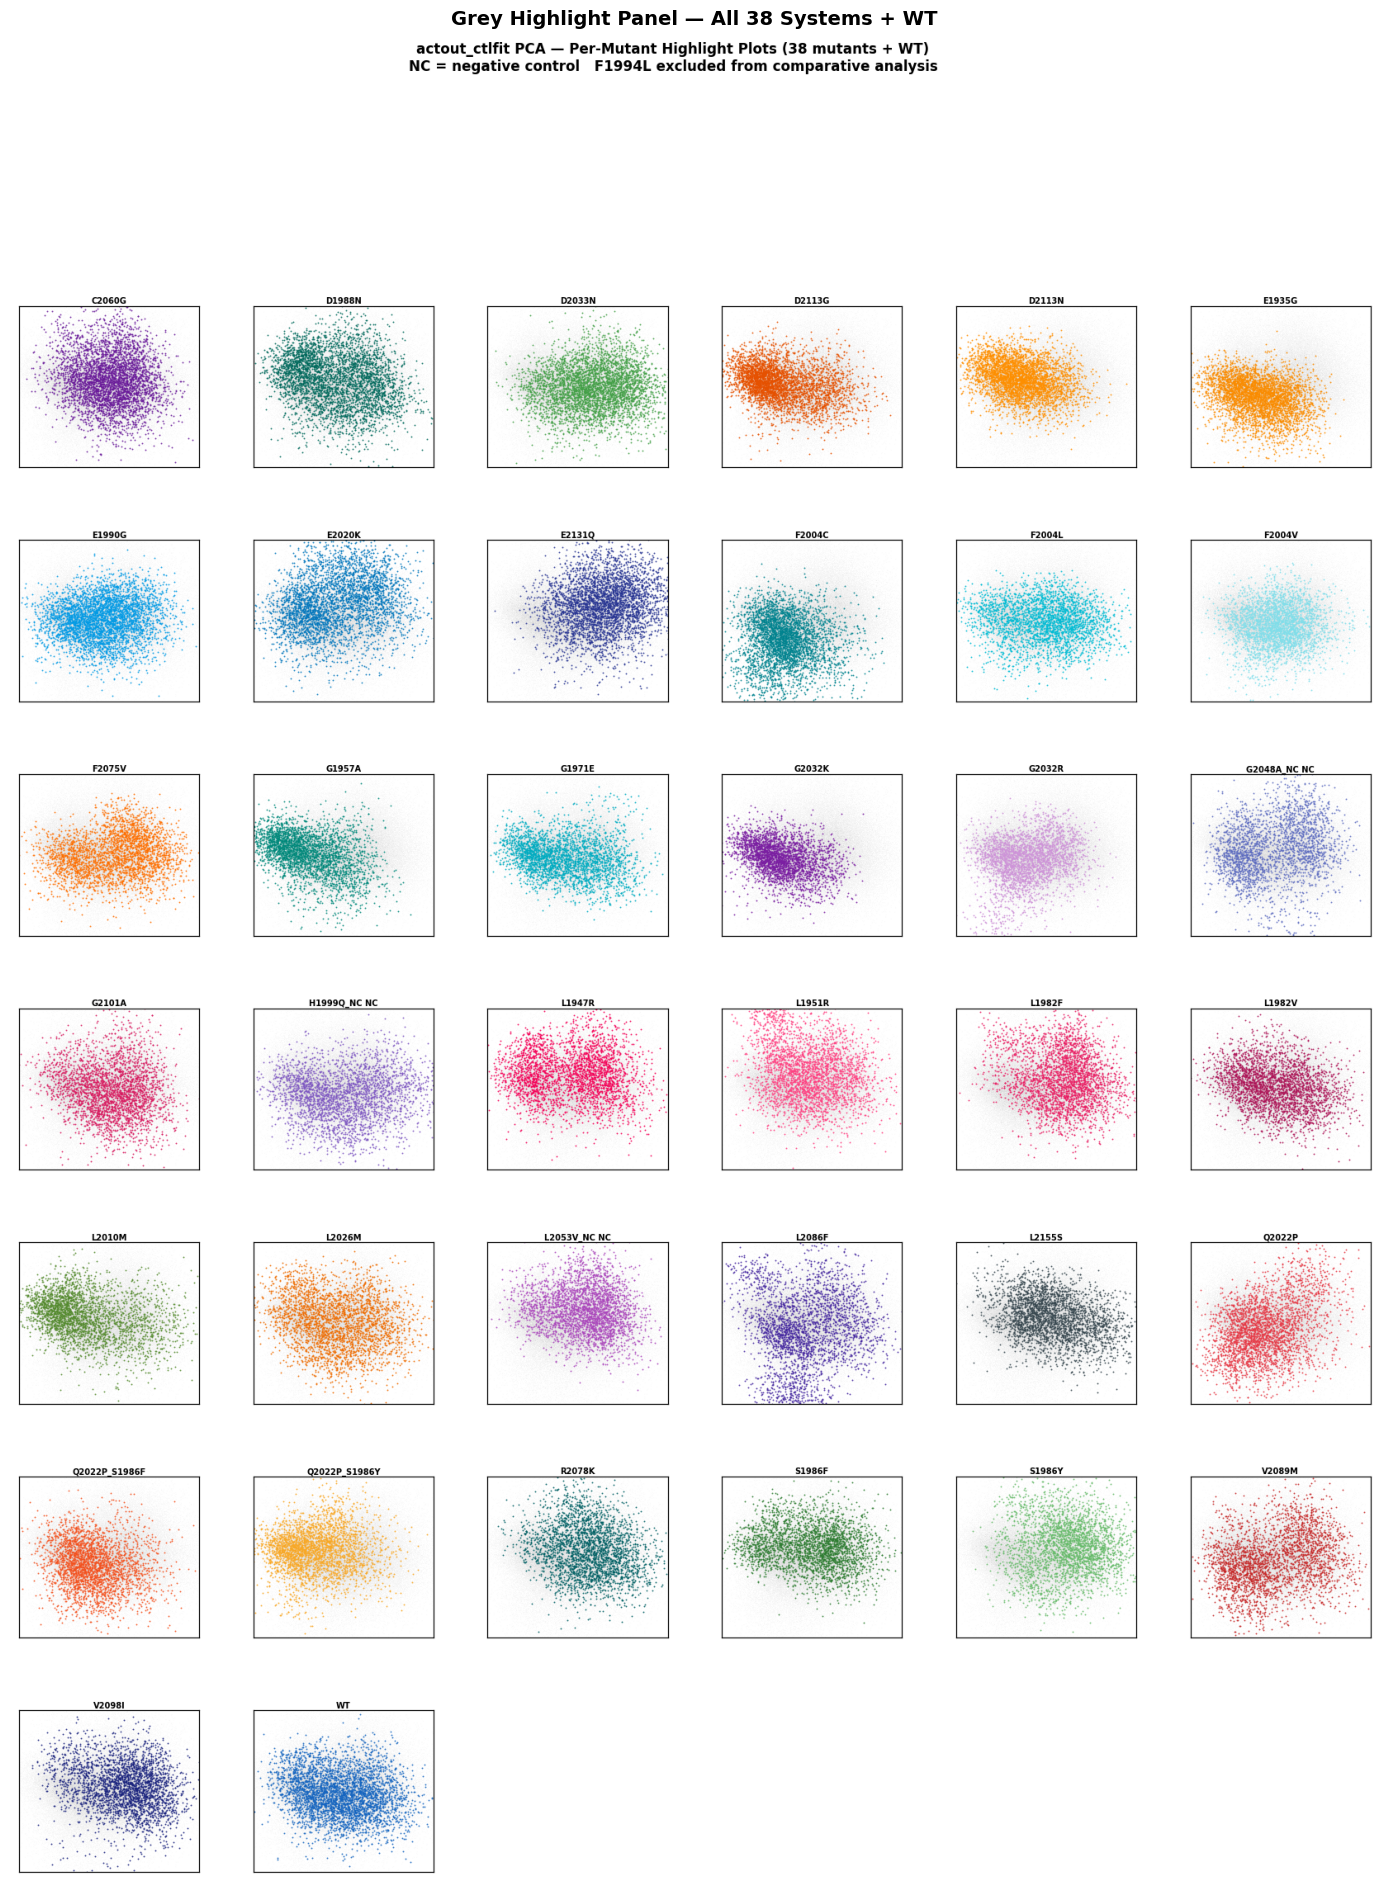

Panel loaded from: /homes/lkgyammerah/Molecular_Dynamics_analysis/figures/ROS1/ros1_prepared_final/grey_highlight/panel_all_highlight.png
Individual plots available: 39


In [22]:
HIGHLIGHT_DIR = '/homes/lkgyammerah/Molecular_Dynamics_analysis/figures/ROS1/ros1_prepared_final/grey_highlight'
panel_path    = os.path.join(HIGHLIGHT_DIR, 'panel_all_highlight.png')

if os.path.exists(panel_path):
    from PIL import Image
    img = Image.open(panel_path)
    plt.figure(figsize=(20, 24))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Grey Highlight Panel — All 38 Systems + WT', fontsize=14, fontweight='bold')
    plt.show()
    print(f'Panel loaded from: {panel_path}')
    n_files = len(glob.glob(os.path.join(HIGHLIGHT_DIR, '*_highlight.png')))
    print(f'Individual plots available: {n_files}')
else:
    print(f'Panel not found at: {panel_path}')
    print('Run generate_grey_highlight_plots.py on the cluster first.')


## Section 9 — CTL FEL Overview

In [23]:
# Load CTL scores — confirmed file
ctl_scores = np.load(os.path.join(BASE, 'ctl_scores.npy'))
ctl_owner  = np.load(os.path.join(BASE, 'ctl_x_owner.npy'))
print(f'CTL scores: {ctl_scores.shape}')
print(f'CTL owner:  {ctl_owner.shape}')

# Check if CTL frame_points CSV exists
ctl_fp_path = os.path.join(BASE, 'ctl_fel_frame_points.csv')
if os.path.exists(ctl_fp_path):
    ctl_fp = pd.read_csv(ctl_fp_path)
    ctl_pc1 = ctl_fp['PC1'].values
    ctl_pc2 = ctl_fp['PC2'].values
    ctl_mut = ctl_fp['mutant'].values
    print(f'CTL frame_points: {ctl_fp.shape}, mutants: {ctl_fp.mutant.nunique()}')
    USE_CTL_FP = True
else:
    print('No CTL frame_points CSV — using owner array (no WT)')
    ctl_pc1 = ctl_scores[:,0]
    ctl_pc2 = ctl_scores[:,1]
    USE_CTL_FP = False

ctl_xlim = (np.percentile(ctl_pc1,0.5), np.percentile(ctl_pc1,99.5))
ctl_ylim = (np.percentile(ctl_pc2,0.5), np.percentile(ctl_pc2,99.5))


CTL scores: (120307, 10)
CTL owner:  (120307,)
CTL frame_points: (120307, 15), mutants: 38


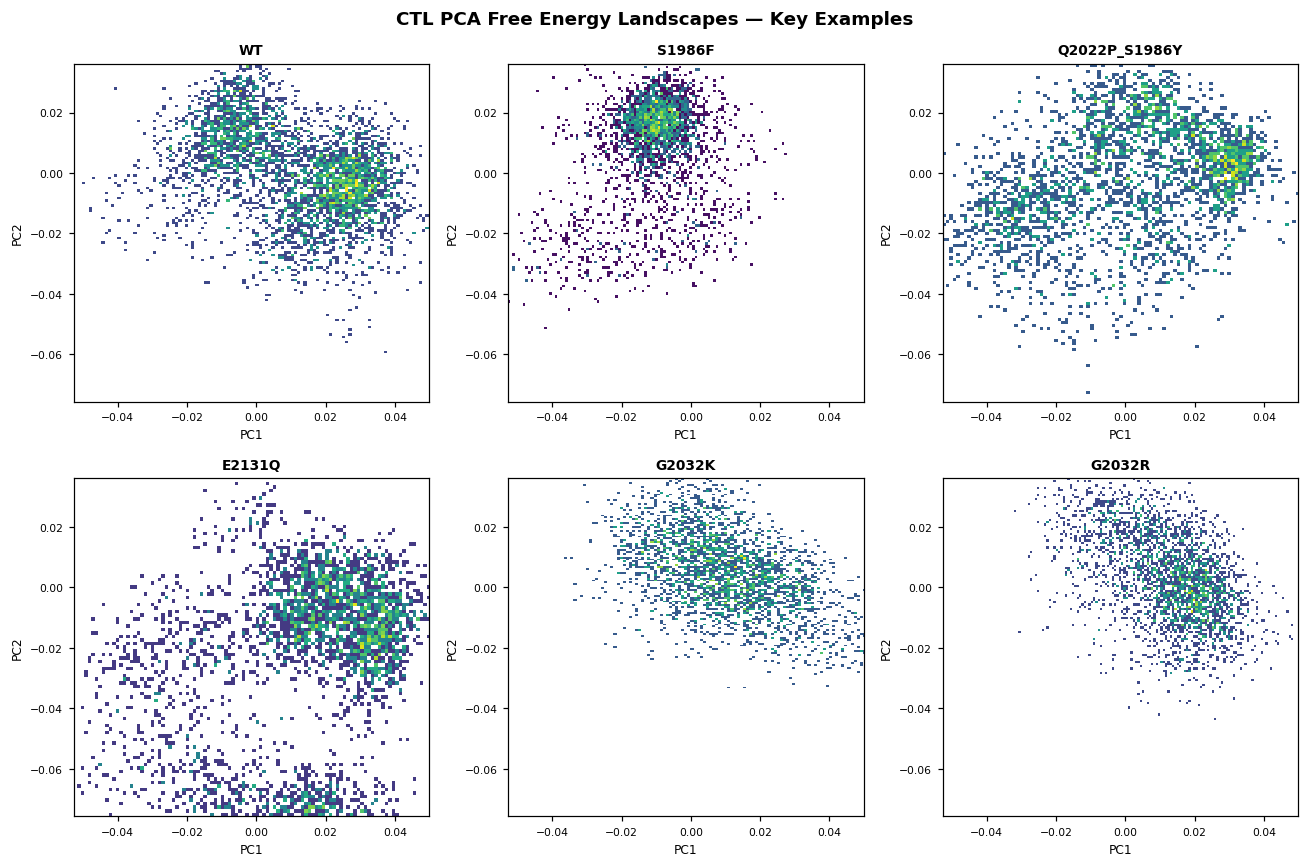

In [24]:
# CTL FEL key examples
CTL_EXAMPLES = ['WT','S1986F','Q2022P_S1986Y','E2131Q','G2032K','G2032R']

fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=110)
axes = axes.flatten()

for k, name in enumerate(CTL_EXAMPLES):
    if USE_CTL_FP:
        mask = ctl_mut == name
        p1, p2 = ctl_pc1[mask], ctl_pc2[mask]
    else:
        if name == 'WT' or name not in FPATHS_ORDER:
            axes[k].set_title(f'{name} (unavailable)', fontsize=9)
            continue
        i = FPATHS_ORDER.index(name)
        mask = np.isin(ctl_owner, [i*3, i*3+1, i*3+2])
        p1, p2 = ctl_pc1[mask], ctl_pc2[mask]
    plot_fel(axes[k], p1, p2, title=name,
              xlim=ctl_xlim, ylim=ctl_ylim)

plt.suptitle('CTL PCA Free Energy Landscapes — Key Examples',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'CTL_FEL_examples.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Section 10 — Docking Results (fill after pipeline completes)

In [25]:
# Expected after running 05a→05aa→05ab→05b→05d→05c
DOCK_DIR  = '/homes/lkgyammerah/Molecular_Dynamics_analysis/analysis'
dock_file = os.path.join(DOCK_DIR, 'vina_results_ranked_q2022p.csv')

if os.path.exists(dock_file):
    df_dock = pd.read_csv(dock_file)
    print(f'Docking results: {df_dock.shape}')
    print(df_dock.columns.tolist())
    print(df_dock.head(20))
else:
    print(f'Docking results not yet available.')
    print(f'Expected at: {dock_file}')
    print('Run pipeline steps 05a → 05aa → 05ab → 05b → 05d → 05c')


Docking results not yet available.
Expected at: /homes/lkgyammerah/Molecular_Dynamics_analysis/analysis/vina_results_ranked_q2022p.csv
Run pipeline steps 05a → 05aa → 05ab → 05b → 05d → 05c


## Section 11 — Export Summary Table

In [26]:
# Build per-mutant summary from confirmed data
summary = pd.DataFrame({'Variant': MUTANTS})

# Frame counts from frame_points
counts = fp.groupby('mutant').size().reset_index(name='N_Frames')
summary = summary.merge(counts, left_on='Variant', right_on='mutant', how='left').drop('mutant',axis=1)

# PC1/PC2 means
means = fp.groupby('mutant')[['PC1','PC2']].mean().reset_index()
means.columns = ['Variant','actout_PC1_mean','actout_PC2_mean']
summary = summary.merge(means, on='Variant', how='left')
summary[['actout_PC1_mean','actout_PC2_mean']] = \
    summary[['actout_PC1_mean','actout_PC2_mean']].round(4)

# DBSCAN noise
summary['DBSCAN_Noise_Pct'] = summary['Variant'].map(noise_dict)

# Classification
def classify(n):
    if n == 'WT':          return 'Reference'
    if n in NC_VARIANTS:   return 'Negative control'
    if '_S1986' in n:      return 'Compound/suppressor'
    return 'Resistance mutant'
summary['Classification'] = summary['Variant'].apply(classify)

print(summary.to_string(index=False))

out_csv = os.path.join(BASE, 'ROS1_variant_summary_table.csv')
summary.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}')


      Variant  N_Frames  actout_PC1_mean  actout_PC2_mean  DBSCAN_Noise_Pct      Classification
       C2060G      3933           0.0110           0.0069              1.27   Resistance mutant
       D1988N      3951          -0.0027           0.0072              1.24   Resistance mutant
       D2033N      3945           0.0356          -0.0047              0.79   Resistance mutant
       D2113G      3805          -0.0400           0.0011              0.16   Resistance mutant
       D2113N      3801          -0.0327           0.0084              0.08   Resistance mutant
       E1935G      3803          -0.0265          -0.0180              0.34   Resistance mutant
       E1990G      3982          -0.0007          -0.0011              0.83   Resistance mutant
       E2020K      3800          -0.0009           0.0226              2.50   Resistance mutant
       E2131Q      3811           0.0546           0.0192              4.28   Resistance mutant
       F2004C      3659          -0.0349